# MLPR LAB 10
### Proshita Agarwal

In [1]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
# Step 2: Generate synthetic data (seed=0 for reproducibility)
np.random.seed(0)

n_total = 500
n1 = n_total // 2
n2 = n_total - n1

mu1 = np.array([2, 2])
sigma1 = np.array([[0.9, -0.0255],
                   [-0.0255, 0.9]])

mu2 = np.array([5, 5])
sigma2 = np.array([[0.5, 0],
                   [0, 0.3]])

class0 = np.random.multivariate_normal(mu1, sigma1, n1)  # label 0
class1 = np.random.multivariate_normal(mu2, sigma2, n2)  # label 1

In [3]:
# Step 3: Combine classes and labels into one dataset
X = np.vstack((class0, class1))                   # shape: (500, 2)
y = np.hstack((np.zeros(n1), np.ones(n2)))        # shape: (500,)

In [4]:
# Step 4: Add bias term (column of ones)
bias_col = np.ones((X.shape[0], 1))
X_bias = np.hstack((X, bias_col))                 # shape: (500, 3)

In [5]:
# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_bias, y, test_size=0.2, random_state=0, stratify=y
)

In [6]:
# Step 6 & 7: Perceptron and step activation function
def step_activation(a):
    return 1 if a >= 0 else 0

def train_perceptron(X, y, lr=0.1, max_epochs=1000):
    w = np.zeros(X.shape[1])  # includes bias weight
    for _ in range(max_epochs):
        errors = 0
        for xi, target in zip(X, y):
            activation = np.dot(w, xi)
            pred = step_activation(activation)
            update = lr * (target - pred)
            if update != 0:
                w += update * xi
                errors += 1
        if errors == 0:  # early stop if perfectly classified
            break
    return w

In [7]:
# Step 8: Train perceptron
w = train_perceptron(X_train, y_train, lr=0.1, max_epochs=1000)
print("Learned weights:", w)

Learned weights: [ 0.1730965   0.21857598 -1.4       ]


In [8]:
# Step 9: Predict on test set and evaluate
def predict_perceptron(X, w):
    activations = np.dot(X, w)
    return (activations >= 0).astype(int)

y_pred = predict_perceptron(X_test, w)
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 1.0


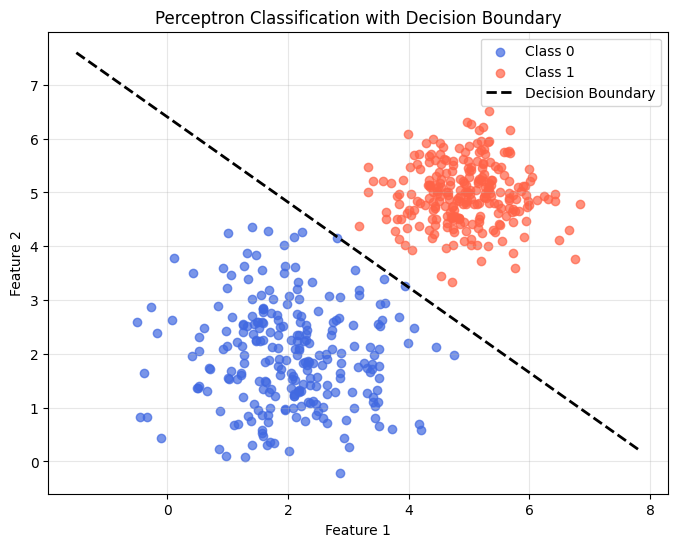

In [9]:
# Step 10: Scatter plot + decision boundary
plt.figure(figsize=(8, 6))
plt.scatter(class0[:, 0], class0[:, 1], c='royalblue', alpha=0.7, label='Class 0')
plt.scatter(class1[:, 0], class1[:, 1], c='tomato', alpha=0.7, label='Class 1')

# Decision boundary: w1*x1 + w2*x2 + w3*1 = 0  =>  x2 = -(w1*x1 + w3)/w2
x_vals = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200)
if abs(w[1]) > 1e-8:
    y_vals = -(w[0]*x_vals + w[2]) / w[1]
    plt.plot(x_vals, y_vals, 'k--', linewidth=2, label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Classification with Decision Boundary")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

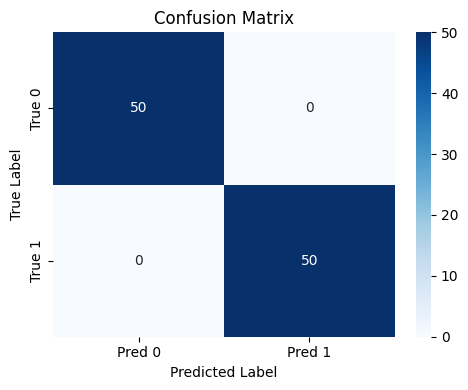

In [10]:
# Step 11: Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Report

### Question 1
Both systems are made of interconnected processing units (neurons in biology, nodes in ANNs) that pass signals to each other. Learning in both happens by adjusting connection strengths, which are synaptic weights biologically and numerical weights in ANNs. They also both use nonlinear transformations to model complex input-output relationships. Finally, both can generalize from past examples to new unseen patterns.

### Question 2
The McCulloch-Pitts model was an early mathematical neuron that took binary inputs, applied fixed weights, and produced a binary output using a threshold rule. It showed that logical computations could be represented with neuron-like units. One limitation is that it only supports binary states and cannot naturally model continuous-valued signals. Another is that it has no built-in learning mechanism, so weights must be manually defined rather than learned from data.

### Question 3
A perceptron learns by iterating through training samples and comparing predicted labels with true labels. If a sample is misclassified, it updates weights and bias using the perceptron update rule, scaled by the learning rate. This shifts the decision boundary to reduce future errors on similar samples. Repeating this for many epochs gradually improves classification when the data is linearly separable.

### Question 4
The step (binary threshold) function outputs either 0 or 1, so its range is {0, 1}. The sigmoid function squashes values into (0, 1), making it useful for probabilities. The hyperbolic tangent (tanh) outputs in (-1, 1), centered around zero. ReLU outputs 0 for negative inputs and the input itself for positive values, so its range is [0, ∞).

### Question 5
A classical single-layer perceptron can only learn one linear decision boundary. XOR is not linearly separable, so no single straight line can separate its classes correctly. A practical solution is to use a multi-layer neural network (at least one hidden layer) with nonlinear activation functions. This lets the model build nonlinear decision regions and solve XOR without explicitly hand-mapping features to a higher-dimensional space.